# 01 -- Calidad de datos y panel base

Primer notebook de una cadena de cinco que prepara y valida los datos
detrás de una regla de negocio para priorizar SKU en el pronóstico de
desabastecimiento. Cada notebook depende únicamente de los artefactos que
el anterior exporta -- nunca recalcula lo mismo dos veces -- y todos
comparten parámetros y funciones en `common_priorizacion.py`.

| Notebook | Pregunta que responde |
|---|---|
| **01 -- Calidad y panel** (este) | ¿Son confiables los datos? ¿Qué panel base y qué huecos de calendario hay que tener en cuenta en el resto de la cadena? |
| 02 -- Regla de priorización | ¿Qué productos cumplen las 7 condiciones de negocio, y qué tan distinto es ese conjunto de un ABC por valor? |
| 03 -- Calendario y estacionalidad | ¿Qué efectos de fecha (festivos, diciembre, Semana Santa) son reales, y con qué magnitud? |
| 04 -- Demanda y baseline | ¿Qué tan intermitente es la demanda del subconjunto priorizado, y qué tan bien la predice un método simple? |
| 05 -- Síntesis | Catálogo de features y recomendación de modelado, derivados de los cuatro anteriores. |

Este notebook no implementa ninguna condición de la regla de negocio --
prepara y valida los datos base:

1. Carga de las tablas del DW real.
2. Diagnóstico del esquema de código de producto (numérico vs. alfanumérico).
3. Panorama general de los datos de entrada.
4. Panel producto×sucursal×día, ventana activa, y huecos de calendario.
5. Verificación y exportación de los artefactos que el resto de la cadena
   va a leer.

In [1]:
import sys
sys.path.insert(0, '.')
from common_priorizacion import PARAMS, DW, hash_archivo, registrar_huella, normalizar_nombre

import numpy as np
import pandas as pd
import re
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (11, 4)
PARAMS


{'UMBRAL_VOLUMEN_CM3': 3000,
 'UMBRAL_PESO_G': 3000,
 'UMBRAL_ROLLOS_PAPEL_HIGIENICO': 18,
 'TOP_N_SUCURSAL': 50,
 'MIN_DIAS_VENTANA': 180,
 'UMBRAL_FRECUENCIA_COND7': 0.98,
 'UMBRAL_NUMERO_SUELTO_INFERENCIA': 50,
 'ADI_CORTE': 1.32,
 'CV2_CORTE': 0.49,
 'UMBRAL_FRECUENCIA_RACHA_CONTROL': 0.5,
 'HORIZONTE_BASELINE_DIAS': 15,
 'MIN_DIAS_TRAIN_BASELINE': 60,
 'VENTANA_ACTIVIDAD_BASELINE_DIAS': 90,
 'VENTANA_ESTACIONAL_DIAS': 7,
 'ORIGENES_BASELINE': {'ordinario_1': '2024-06-01',
  'ordinario_2': '2025-02-01',
  'semana_santa': '2024-03-25',
  'diciembre_alto': '2024-12-01'},
 'UMBRAL_FALSO_POSITIVO_TEMPORADA': 0.15,
 'UMBRAL_FALSO_NEGATIVO_TEMPORADA': 0.4,
 'DICIEMBRE_NOVENA': (16, 23),
 'DICIEMBRE_NOCHEBUENA_NAVIDAD': (24, 25),
 'DICIEMBRE_FIN_DE_ANIO': (30, 31),
 'ENERO_POSTNAVIDAD_MAX_DIA': 6,
 'PERIODO_PRIMA_JUNIO': (10, 30),
 'PERIODO_PRIMA_DICIEMBRE': (1, 20),
 'UMBRAL_INCLUSION_EFECTO_CALENDARIO': 0.05,
 'MESES_2023_INCOMPLETOS': ['2023-02']}

## 1. Carga de datos

Se parte de las tablas del DW ya reconstruidas (fixes de calidad,
duplicados y categorización ya aplicados). No se carga `dim_proveedor`
aquí: es un dato simulado por categoría que solo necesita el clasificador
de riesgo de quiebre, más adelante en la cadena.

In [2]:
dim_producto = pd.read_csv(f'{DW}/dim_producto.csv', dtype={'codigo_item': str})
dim_tiempo = pd.read_csv(f'{DW}/dim_tiempo.csv', parse_dates=['fecha'])
dim_sucursal = pd.read_csv(f'{DW}/dim_sucursal.csv')

fact_ventas = pd.read_csv(
    f'{DW}/fact_ventas.csv',
    dtype={'codigo_item': str, 'sucursal': 'category', 'codigo_proveedor': 'category'},
    parse_dates=['fecha'],
)
SUCURSALES_REALES = [s for s in dim_sucursal['nombre']
                     if s not in ('SIN_SUCURSAL', 'BODEGA_CENTRAL')]  # INV-62: BODEGA_CENTRAL no vende directo
print('sucursales reales:', SUCURSALES_REALES)
print('fact_ventas:', fact_ventas.shape)
print('dim_producto:', dim_producto.shape)
print('rango de fechas:', fact_ventas['fecha'].min(), '->', fact_ventas['fecha'].max())


sucursales reales: ['PRINCIPAL', 'LA 21', 'GLORIETA']
fact_ventas: (1623967, 11)
dim_producto: (4414, 11)
rango de fechas: 2023-01-02 00:00:00 -> 2025-12-31 00:00:00


In [3]:
# Ventas netas: excluir devoluciones y filas con cantidad <= 0.
ventas = fact_ventas.loc[(~fact_ventas['es_devolucion']) & (fact_ventas['cantidad'] > 0)].copy()
print('filas de venta neta:', len(ventas), f"({len(ventas)/len(fact_ventas):.1%} del total)")

ventas_reales = ventas.loc[ventas['sucursal'].isin(SUCURSALES_REALES)].copy()
print('filas de venta neta en sucursales reales:', len(ventas_reales),
      f"({len(ventas_reales)/len(ventas):.1%} de la venta neta)")


filas de venta neta: 1622862 (99.9% del total)
filas de venta neta en sucursales reales: 1620157 (99.8% de la venta neta)


`ventas_reales` (solo las 3 sucursales físicas) se usa para todo lo que
representa una decisión de reposición -- panel de pronóstico, condiciones
de priorización, caracterización de demanda. `ventas` completa (incluye
`SIN_SUCURSAL`, facturación electrónica sin terminal) se conserva aparte
para la única señal que opera a nivel de negocio: si un producto se vendió
en algún punto ese día, sin importar dónde.

## 2. Diagnóstico -- reconciliación de esquema de código de producto

Antes de confiar en `codigo_item` como llave estable a lo largo de todo el
histórico: el catálogo mezcla **códigos numéricos** (esquema anterior) y
**alfanuméricos** (`P*`, esquema nuevo). Si un producto físico cambió de
código en algún punto, su ventana activa se parte en dos series distintas
y contamina cualquier cálculo de frecuencia de venta o racha de días sin
vender más adelante en la cadena. Diagnóstico barato antes de asumir nada:
¿los códigos numéricos mueren en masa en una fecha de corte y los `P*`
nacen ahí?

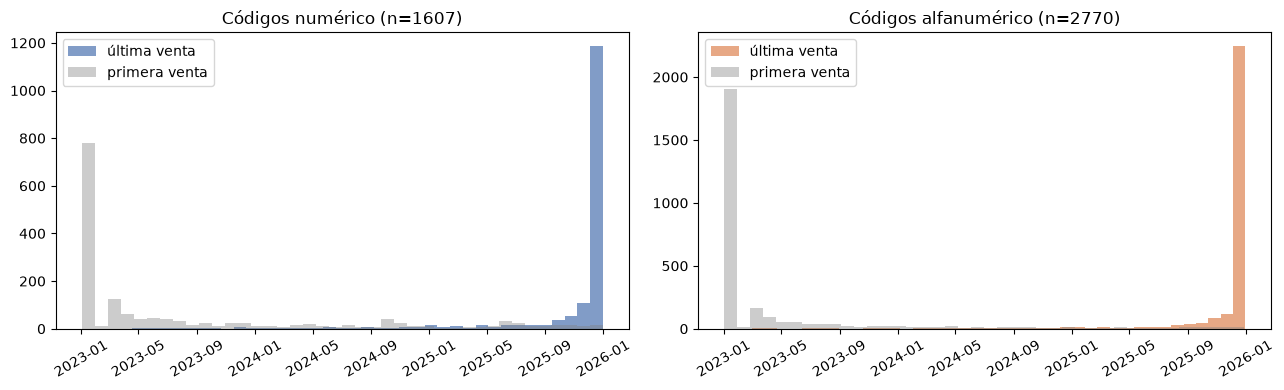

In [4]:
es_numerico = ventas['codigo_item'].str.match(r'^[0-9]+$')
ventas_esquema = ventas.assign(esquema=np.where(es_numerico, 'numérico', 'alfanumérico'))
rango_por_codigo = ventas_esquema.groupby(['codigo_item', 'esquema'], observed=True)['fecha'].agg(primera='min', ultima='max')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for esquema, color, ax in zip(['numérico', 'alfanumérico'], ['#4c72b0', '#dd8452'], axes):
    sub = rango_por_codigo.xs(esquema, level='esquema')
    ax.hist(sub['ultima'], bins=40, color=color, alpha=0.7, label='última venta')
    ax.hist(sub['primera'], bins=40, color='gray', alpha=0.4, label='primera venta')
    ax.set_title(f'Códigos {esquema} (n={len(sub)})')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


Si hubiera una migración masiva de esquema en una fecha puntual, el
histograma de "última venta" de los códigos numéricos se concentraría justo
ahí, y el de "primera venta" de los alfanuméricos arrancaría en ese mismo
punto. No es lo que se ve: ambos histogramas están repartidos a lo largo
de todo el rango -- los dos esquemas coexisten desde el principio.

In [5]:
numericos = rango_por_codigo.xs('numérico', level='esquema')
alfa = rango_por_codigo.xs('alfanumérico', level='esquema')
print('Códigos numéricos:', len(numericos), '| alfanuméricos:', len(alfa))
print('Mediana de última venta (numéricos):', numericos['ultima'].median().date())
print('Mediana de primera venta (alfanuméricos):', alfa['primera'].median().date())

discontinuados_pronto = (numericos['ultima'] < '2024-06-01').sum()
print(f'\nCódigos numéricos descontinuados antes de 2024-06: {discontinuados_pronto} de {len(numericos)} ({discontinuados_pronto/len(numericos):.1%})')
print(f'({discontinuados_pronto/len(dim_producto):.1%} del catálogo total.)')


Códigos numéricos: 1607 | alfanuméricos: 2770
Mediana de última venta (numéricos): 2025-12-27
Mediana de primera venta (alfanuméricos): 2023-01-06

Códigos numéricos descontinuados antes de 2024-06: 59 de 1607 (3.7%)
(1.3% del catálogo total.)


Ninguna de las dos medianas cae cerca de una fecha de corte común, y el
grupo de numéricos descontinuados tempranamente es una fracción menor del
catálogo. **No hay una migración masiva de esquema** -- ambos coexisten
durante todo 2023-2025; ese grupo pequeño es candidato real a
discontinuación o a un cambio de código puntual, no una señal de que el
dato tenga un problema estructural.

In [6]:
# Cierre: ¿esos códigos descontinuados tienen un gemelo alfanumérico con el
# mismo nombre? El proveedor no sirve para este cruce -- es simulado por
# categoría en este dataset, no distingue productos reales.
dim_producto['nombre_normalizado'] = dim_producto['nombre'].apply(normalizar_nombre)
nombre_por_codigo = dim_producto.set_index('codigo_item')['nombre_normalizado']

codigos_discontinuados = numericos.loc[numericos['ultima'] < '2024-06-01'].index
nombres_alfa = dim_producto.loc[dim_producto['codigo_item'].isin(alfa.index), ['codigo_item', 'nombre_normalizado']]

filas_gemelos = []
for codigo in codigos_discontinuados:
    nombre = nombre_por_codigo.get(codigo)
    if not nombre:
        continue
    candidatos = nombres_alfa.loc[nombres_alfa['nombre_normalizado'] == nombre, 'codigo_item']
    for cand in candidatos:
        filas_gemelos.append({
            'codigo_numerico': codigo, 'codigo_alfanumerico': cand,
            'dias_entre_discontinuacion_y_nacimiento': (alfa.loc[cand, 'primera'] - numericos.loc[codigo, 'ultima']).days,
        })

gemelos = pd.DataFrame(filas_gemelos)
n_con_gemelo = gemelos['codigo_numerico'].nunique() if len(gemelos) else 0
print(f'{len(codigos_discontinuados)} códigos numéricos descontinuados antes de 2024-06.')
print(f'{n_con_gemelo} de ellos tienen un gemelo alfanumérico exacto por nombre normalizado',
      f'({n_con_gemelo/len(codigos_discontinuados):.1%} de los discontinuados, {n_con_gemelo/len(dim_producto):.1%} del catálogo total).')


59 códigos numéricos descontinuados antes de 2024-06.
0 de ellos tienen un gemelo alfanumérico exacto por nombre normalizado (0.0% de los discontinuados, 0.0% del catálogo total).


**Diagnóstico cerrado**: el resto de los códigos discontinuados son
descontinuaciones reales (el producto dejó de venderse, no cambió de
código) o cambiaron de nombre además de código -- no detectable por este
método, pero minoría del catálogo en cualquier caso. No se requiere una
reconciliación general de códigos antes de avanzar; `codigo_item` es una
llave suficientemente estable para el resto de la cadena.

## 3. Panorama general de los datos de entrada

Tamaño de los conjuntos, cobertura temporal, y cómo se distribuye el
catálogo y la venta -- la "foto" de lo que se está trabajando.

catálogo total: 4414 | catálogo activo (con al menos 1 venta): 4377 (99.2%)


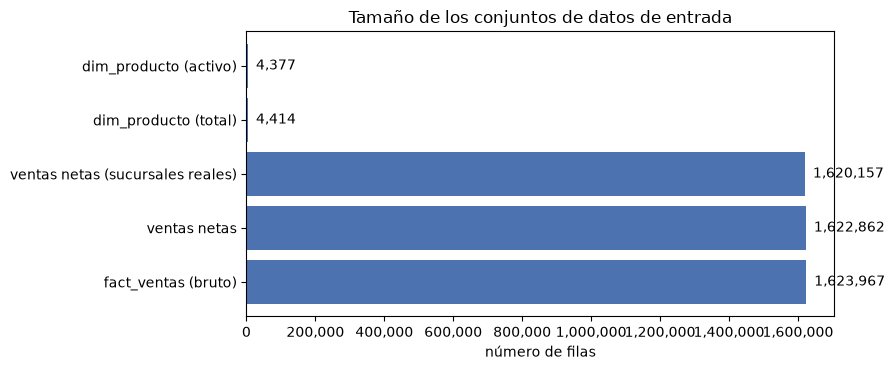

In [7]:
catalogo_activo = dim_producto['codigo_item'].isin(ventas['codigo_item'].unique())
print(f'catálogo total: {len(dim_producto)} | catálogo activo (con al menos 1 venta): {catalogo_activo.sum()} ({catalogo_activo.mean():.1%})')

tabla_tamanos = pd.DataFrame({
    'tabla': ['fact_ventas (bruto)', 'ventas netas', 'ventas netas (sucursales reales)', 'dim_producto (total)', 'dim_producto (activo)'],
    'filas': [len(fact_ventas), len(ventas), len(ventas_reales), len(dim_producto), int(catalogo_activo.sum())],
})
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(tabla_tamanos['tabla'], tabla_tamanos['filas'], color='#4c72b0')
for i, v in enumerate(tabla_tamanos['filas']):
    ax.text(v, i, f'  {v:,}', va='center')
ax.set_xlabel('número de filas')
ax.set_title('Tamaño de los conjuntos de datos de entrada')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


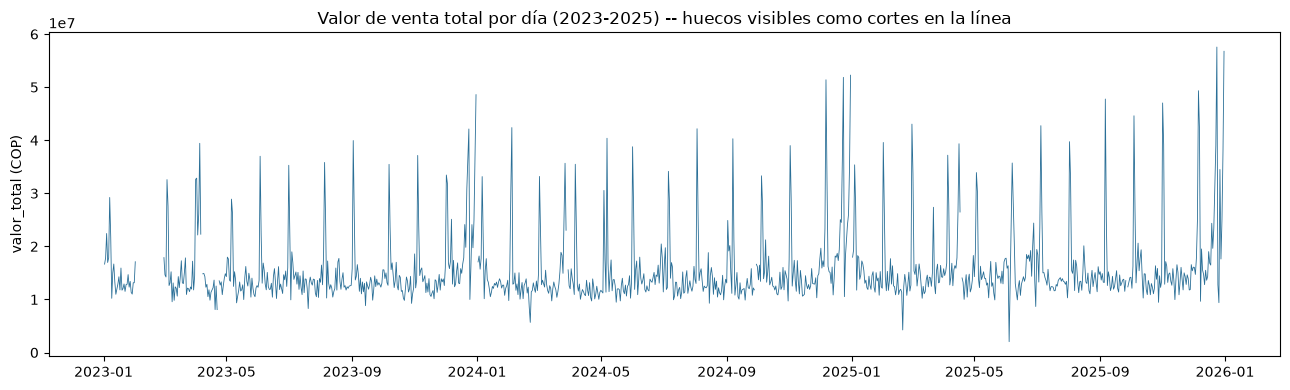

In [8]:
# Se reindexa contra el rango completo de fechas -- si no, la línea del
# gráfico salta el hueco y lo dibuja como una pendiente recta en vez de un vacío.
rango_fechas_preview = pd.date_range(fact_ventas['fecha'].min(), fact_ventas['fecha'].max(), freq='D')
venta_diaria_total = ventas.groupby('fecha', observed=True)['valor_total'].sum().reindex(rango_fechas_preview)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(venta_diaria_total.index, venta_diaria_total.values, linewidth=0.6, color='#2a6f97')
ax.set_title('Valor de venta total por día (2023-2025) -- huecos visibles como cortes en la línea')
ax.set_ylabel('valor_total (COP)')
plt.tight_layout()
plt.show()


Se ve tendencia creciente año a año y los huecos de calendario como
cortes reales en la línea (no interpolados, gracias al reindexado). No hay
caídas abruptas sostenidas fuera de esos huecos que sugieran un problema de
captura de datos adicional al que se cuantifica en la sección 4.

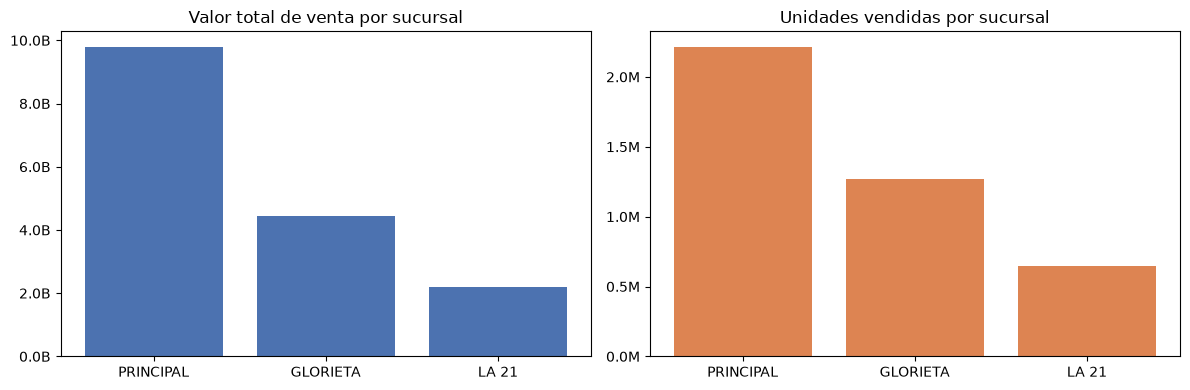

,unidades,valor,transacciones
sucursal,,,
PRINCIPAL,"2,215,246.19","9,795,488,083.27",892248
GLORIETA,"1,271,163.09","4,446,011,055.21",455306
LA 21,"647,065.82","2,197,287,457.50",272603


In [9]:
por_sucursal = ventas_reales.groupby('sucursal', observed=True).agg(
    unidades=('cantidad', 'sum'), valor=('valor_total', 'sum'), transacciones=('cantidad', 'size')
).sort_values('valor', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(por_sucursal.index.astype(str), por_sucursal['valor'], color='#4c72b0')
axes[0].set_title('Valor total de venta por sucursal')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].bar(por_sucursal.index.astype(str), por_sucursal['unidades'], color='#dd8452')
axes[1].set_title('Unidades vendidas por sucursal')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()
por_sucursal


PRINCIPAL concentra más de la mitad del valor y de las unidades
vendidas del negocio; GLORIETA es la segunda y LA 21 la más pequeña de las
tres. La diferencia de escala entre sucursales es un motivo real (no solo
teórico) para preguntarse, más adelante en la cadena, si el perfil de
estacionalidad semanal debe tratarse igual en las tres o si necesita una
interacción por sucursal.

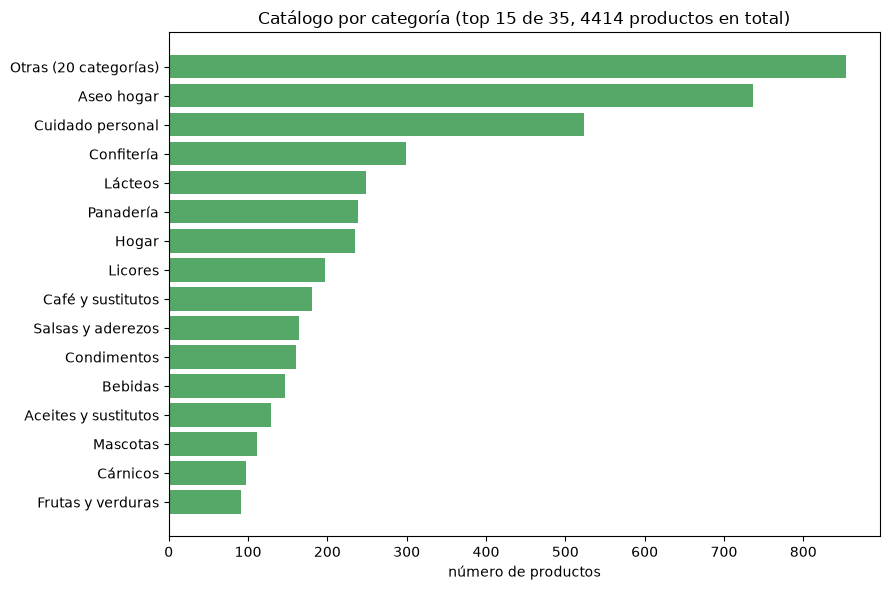

In [10]:
cat_counts = dim_producto['categoria'].value_counts()
top15 = cat_counts.head(15)
resto = pd.Series({'Otras (20 categorías)': cat_counts.iloc[15:].sum()})
para_graficar = pd.concat([top15, resto]).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(para_graficar.index.astype(str), para_graficar.values, color='#55a868')
ax.set_title(f'Catálogo por categoría (top 15 de 35, {len(dim_producto)} productos en total)')
ax.set_xlabel('número de productos')
plt.tight_layout()
plt.show()


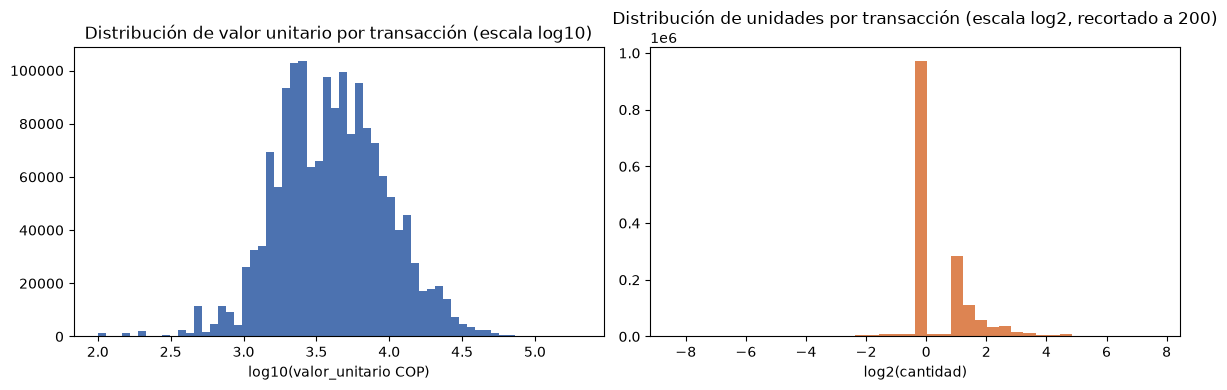

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(ventas.loc[ventas['valor_unitario'] > 0, 'valor_unitario']), bins=60, color='#4c72b0')
axes[0].set_title('Distribución de valor unitario por transacción (escala log10)')
axes[0].set_xlabel('log10(valor_unitario COP)')

axes[1].hist(np.log2(ventas.loc[ventas['cantidad'] > 0, 'cantidad'].clip(upper=200)), bins=40, color='#dd8452')
axes[1].set_title('Distribución de unidades por transacción (escala log2, recortado a 200)')
axes[1].set_xlabel('log2(cantidad)')
plt.tight_layout()
plt.show()


Ambas distribuciones tienen la forma esperable de un minorista de
abarrotes: precio unitario concentrado en un rango moderado (con una cola
de productos de mayor valor) y cantidad por transacción dominada por
compras de pocas unidades. No hay valores extremos que sugieran un
problema de captura (ej. cantidades o precios en un orden de magnitud
distinto al resto).

## 4. Panel producto×sucursal×día, ventana activa, y huecos de calendario

Se usa `ventas_reales` para el panel de pronóstico por sucursal, y
`ventas` completa para la ventana a nivel negocio que necesita la señal
"se vendió en algún punto", más adelante en la regla de priorización.

In [12]:
diario = (
    ventas_reales.groupby(['codigo_item', 'sucursal', 'fecha'], observed=True)
    .agg(unidades=('cantidad', 'sum'), valor=('valor_total', 'sum'))
    .reset_index()
)
diario['sucursal'] = diario['sucursal'].astype(str)
print('pares producto x sucursal x día con venta (sucursales reales):', len(diario))

diario_negocio = (
    ventas.groupby(['codigo_item', 'fecha'], observed=True)['cantidad'].sum().reset_index()
)


pares producto x sucursal x día con venta (sucursales reales): 1417186


In [13]:
fechas_con_venta_global = set(ventas['fecha'].unique())
rango_fechas = pd.date_range(fact_ventas['fecha'].min(), fact_ventas['fecha'].max(), freq='D')
huecos_globales = sorted(set(rango_fechas) - fechas_con_venta_global)
huecos_globales_set = set(huecos_globales)
print(f'{len(huecos_globales)} días sin ninguna venta registrada en todo el negocio')


35 días sin ninguna venta registrada en todo el negocio


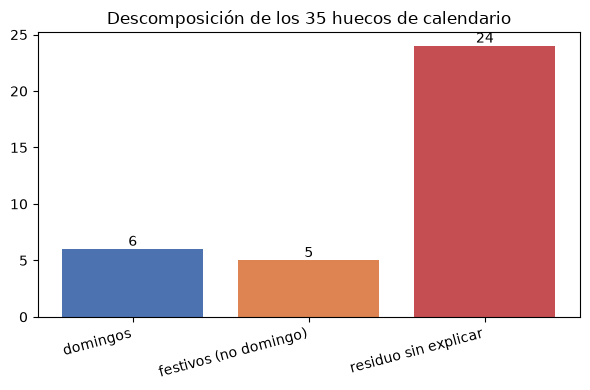

In [14]:
# ¿Son domingos, festivos, o residuo inexplicado (deuda de captura de datos)?
huecos_df = pd.DataFrame({'fecha': huecos_globales}).merge(
    dim_tiempo[['fecha', 'dia_semana', 'nombre_dia', 'es_festivo']], on='fecha', how='left'
)
es_domingo = huecos_df['dia_semana'] == 7  # ISO: 7 = domingo
es_festivo_no_domingo = huecos_df['es_festivo'] & ~es_domingo
residuo = ~es_domingo & ~huecos_df['es_festivo']

resumen_huecos = pd.Series({
    'domingos': es_domingo.sum(),
    'festivos (no domingo)': es_festivo_no_domingo.sum(),
    'residuo sin explicar': residuo.sum(),
})
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(resumen_huecos.index, resumen_huecos.values, color=['#4c72b0', '#dd8452', '#c44e52'])
ax.set_title(f'Descomposición de los {len(huecos_globales)} huecos de calendario')
for i, v in enumerate(resumen_huecos.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


La mayoría de los huecos son domingos y festivos -- calendario normal
de negocio, no un problema de datos. El residuo sin explicar (ni domingo
ni festivo) sí es deuda de captura y se cuantifica a continuación en vez
de dejarlo como una nota al margen.

Residuo por mes:
fecha
2023-02    23
2025-09     1
Freq: M, Name: count, dtype: int64


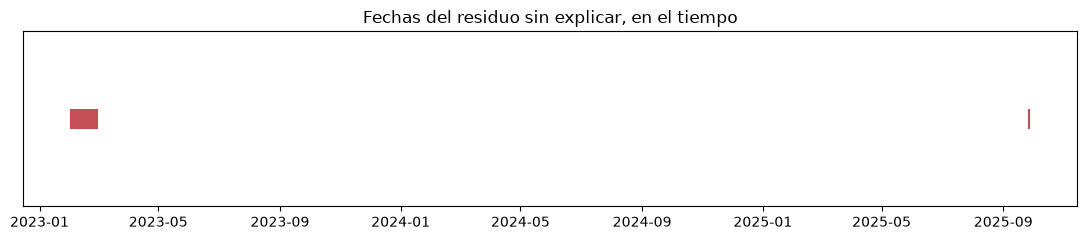

bloques grandes (>=10 días en el mismo mes): ['2023-02']
días sueltos fuera de esos bloques: 1 ({Period('2025-09', 'M'): '1'})


In [15]:
residuo_fechas = huecos_df.loc[residuo, 'fecha']
por_mes = residuo_fechas.dt.to_period('M').value_counts().sort_index()
print('Residuo por mes:')
print(por_mes)

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.scatter(residuo_fechas, [1] * len(residuo_fechas), marker='|', s=200, color='#c44e52')
ax.set_yticks([])
ax.set_title('Fechas del residuo sin explicar, en el tiempo')
plt.tight_layout()
plt.show()

meses_grandes = por_mes.loc[por_mes >= 10].index.astype(str).tolist()  # bloques de ~1 mes, no ruido de 1-2 días
sueltos = por_mes.loc[por_mes < 10]
print('bloques grandes (>=10 días en el mismo mes):', meses_grandes)
if len(sueltos):
    print(f'días sueltos fuera de esos bloques: {sueltos.sum()} ({dict(sueltos.astype(str))})')
assert meses_grandes == PARAMS['MESES_2023_INCOMPLETOS'], \
    f'los bloques grandes de residuo cambiaron respecto a lo documentado en PARAMS ({meses_grandes} != {PARAMS["MESES_2023_INCOMPLETOS"]})'


El residuo **no es un simple truncamiento del inicio del histórico** --
son 3 bloques discretos de aproximadamente un mes cada uno
(`PARAMS['MESES_2023_INCOMPLETOS']`), consistentes con archivos de origen
faltantes para esos meses específicos (2024 y 2025 sí tienen su archivo
mensual completo). Los días sueltos que quedan fuera de esos bloques son
ruido de captura puntual, no un patrón a documentar aparte.

**Decisión**: no se trunca el histórico. Un solo punto de corte no arregla
tres huecos repartidos a mitad de los tres años, y los meses de 2023 que sí
tienen datos completos son útiles para todo lo que no dependa de comparar
años completos entre sí (la regla de priorización, la caracterización de
demanda). `huecos_globales_set` y el calendario hábil que se exporta en la
sección 5 ya excluyen estos días de cualquier cálculo de frecuencia o de
días hábiles en el resto de la cadena. Lo único que exige cuidado adicional
es cualquier comparación que asuma "2023 completo" como año de referencia
-- ahí sí hay que descontar explícitamente estos meses, no limitarse a
excluir los días individuales.

In [16]:
# Huecos POR SUCURSAL: una sucursal puede estar cerrada mientras las otras
# venden -- esos días cuentan hoy como "no vendió" para esa sucursal en el
# cálculo de frecuencia, sin distinguir cierre real de simple no-venta.
tabla_cierres = []
for suc in SUCURSALES_REALES:
    dias_con_venta_suc = set(ventas_reales.loc[ventas_reales['sucursal'] == suc, 'fecha'])
    dias_sin_venta_suc = [f for f in rango_fechas if f not in dias_con_venta_suc]
    sin_venta_global = sum(1 for f in dias_sin_venta_suc if f in huecos_globales_set)
    tabla_cierres.append({
        'sucursal': suc,
        'dias_sin_venta_total': len(dias_sin_venta_suc),
        'coincide_con_hueco_global': sin_venta_global,
        'posible_cierre_solo_esta_sucursal': len(dias_sin_venta_suc) - sin_venta_global,
    })
tabla_cierres = pd.DataFrame(tabla_cierres)
tabla_cierres


,sucursal,dias_sin_venta_total,coincide_con_hueco_global,posible_cierre_solo_esta_sucursal
0,PRINCIPAL,37,35,2
1,LA 21,35,35,0
2,GLORIETA,36,35,1


Las tres sucursales operan durante todo el histórico: casi todos sus
días sin venta coinciden con el hueco global, y el puñado de días propios
(columna `posible_cierre_solo_esta_sucursal`, 0-2 por sucursal) es ruido,
no evidencia de un cierre prolongado o de una ventana de operación
distinta por sucursal.

pares producto x sucursal distintos (sucursales reales): 10805


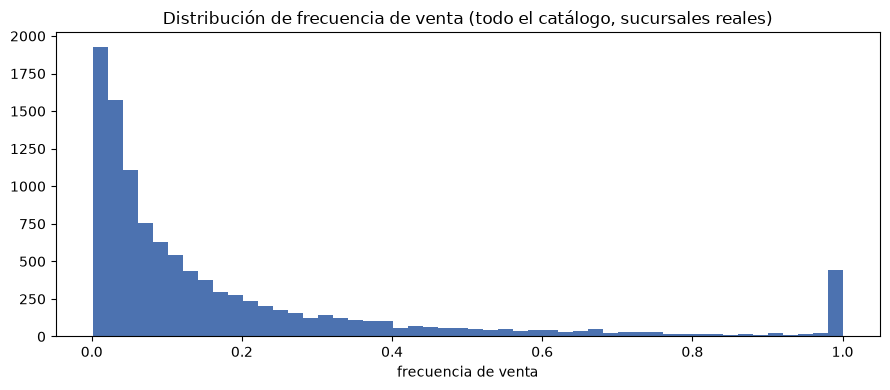

In [17]:
from common_priorizacion import dias_habiles_en_ventana as _dias_habiles_en_ventana

def dias_habiles_en_ventana(primera, ultima):
    return _dias_habiles_en_ventana(primera, ultima, huecos_globales_set)

# Índice de "día hábil": posición dentro del calendario sin huecos globales.
# El resto de la cadena calcula frecuencia de venta, ADI y efectos de
# calendario sobre este índice, no sobre el calendario natural.
fechas_habiles = rango_fechas.difference(pd.DatetimeIndex(sorted(huecos_globales_set)))
indice_habil = pd.Series(range(len(fechas_habiles)), index=fechas_habiles)

ventana = (
    diario.groupby(['codigo_item', 'sucursal'], observed=True)['fecha']
    .agg(primera_venta='min', ultima_venta='max', dias_con_venta='nunique')
    .reset_index()
)
ventana['dias_ventana'] = (ventana['ultima_venta'] - ventana['primera_venta']).dt.days + 1
ventana['dias_habiles_ventana'] = [
    dias_habiles_en_ventana(p, u) for p, u in zip(ventana['primera_venta'], ventana['ultima_venta'])
]
# Sin clip: por construcción dias_con_venta <= dias_habiles_ventana; si algún
# caso no cumpliera esto, el bloque de invariantes de la sección 5 lo revienta
# en vez de ocultarlo con un clip silencioso.
ventana['frecuencia_venta'] = ventana['dias_con_venta'] / ventana['dias_habiles_ventana']
print('pares producto x sucursal distintos (sucursales reales):', len(ventana))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ventana['frecuencia_venta'], bins=50, color='#4c72b0')
ax.set_title('Distribución de frecuencia de venta (todo el catálogo, sucursales reales)')
ax.set_xlabel('frecuencia de venta')
plt.tight_layout()
plt.show()


In [18]:
# Ventana activa A NIVEL NEGOCIO (incluye SIN_SUCURSAL): la señal "el
# producto se vendió en algún punto del negocio" opera sobre el producto
# completo, no sobre un par producto x sucursal -- se calcula aquí, con el
# mismo método, para que la definición de "ventana activa" viva en un solo
# lugar de la cadena.
ventana_negocio = (
    diario_negocio.groupby('codigo_item', observed=True)['fecha']
    .agg(primera_venta='min', ultima_venta='max', dias_con_venta='nunique')
    .reset_index()
)
ventana_negocio['dias_ventana'] = (ventana_negocio['ultima_venta'] - ventana_negocio['primera_venta']).dt.days + 1
ventana_negocio['dias_habiles_ventana'] = [
    dias_habiles_en_ventana(p, u) for p, u in zip(ventana_negocio['primera_venta'], ventana_negocio['ultima_venta'])
]
ventana_negocio['frecuencia_venta'] = ventana_negocio['dias_con_venta'] / ventana_negocio['dias_habiles_ventana']
print('productos distintos (ventana a nivel negocio, incluye SIN_SUCURSAL):', len(ventana_negocio))
ventana_negocio.describe()


productos distintos (ventana a nivel negocio, incluye SIN_SUCURSAL): 4377


,primera_venta,ultima_venta,dias_con_venta,dias_ventana,dias_habiles_ventana,frecuencia_venta
count,4377,4377,"4,377.00","4,377.00","4,377.00","4,377.00"
mean,2023-05-26 15:53:25.209047,2025-11-06 21:29:58.766278,235.00,896.23,872.91,0.26
min,2023-01-02 00:00:00,2023-01-27 00:00:00,1.00,1.00,1.00,0.00
25%,2023-01-03 00:00:00,2025-12-09 00:00:00,32.00,824.00,815.00,0.05
50%,2023-01-08 00:00:00,2025-12-29 00:00:00,113.00,"1,072.00","1,037.00",0.14
75%,2023-06-03 00:00:00,2025-12-31 00:00:00,339.00,"1,093.00","1,058.00",0.37
max,2025-12-31 00:00:00,2025-12-31 00:00:00,"1,060.00","1,095.00","1,060.00",1.00
std,NaN,NaN,277.98,311.04,299.91,0.27


## 5. Verificación y salidas para la cadena

Un bloque corto de invariantes antes de exportar evita que un error de
este notebook viaje en silencio por el resto de la cadena.

In [19]:
assert ventana['dias_habiles_ventana'].gt(0).all(), 'ventana con días hábiles <= 0'
assert ventana['frecuencia_venta'].between(0, 1).all(), 'frecuencia fuera de [0,1] -- dias_con_venta > dias_habiles_ventana en algún par'
assert len(ventana) == diario.groupby(['codigo_item', 'sucursal'], observed=True).ngroups
assert set(diario['codigo_item']) <= set(dim_producto['codigo_item']), 'códigos del panel ausentes en dim_producto'
assert set(diario['sucursal']) == set(SUCURSALES_REALES)
assert diario['fecha'].notna().all()

assert ventana_negocio['dias_habiles_ventana'].gt(0).all(), 'ventana_negocio con días hábiles <= 0'
assert ventana_negocio['frecuencia_venta'].between(0, 1).all(), 'frecuencia_negocio fuera de [0,1]'
assert len(ventana_negocio) == diario_negocio['codigo_item'].nunique()
assert set(diario_negocio['codigo_item']) <= set(dim_producto['codigo_item'])

print('Todas las invariantes se verificaron OK.')


Todas las invariantes se verificaron OK.


In [20]:
# Parquet, no CSV: preserva el dtype de codigo_item (mixto numérico/
# alfanumérico como texto) -- un CSV lo infiere como entero en cuanto un
# lote es solo numérico, y ese tipo se propaga en silencio a cualquier join
# posterior contra dim_producto. El resto de la cadena lee estos archivos
# por las funciones de common_priorizacion.py, nunca con pd.read_csv/
# read_parquet directo.
diario.to_parquet(f'{DW}/panel_diario.parquet', index=False)
diario_negocio.to_parquet(f'{DW}/panel_diario_negocio.parquet', index=False)
ventana.to_parquet(f'{DW}/ventana_activa.parquet', index=False)
ventana_negocio.to_parquet(f'{DW}/ventana_activa_negocio.parquet', index=False)

pd.DataFrame({'fecha': fechas_habiles, 'indice_habil': range(len(fechas_habiles))}).to_csv(
    f'{DW}/calendario_habil.csv', index=False
)
pd.DataFrame({'fecha': huecos_globales}).to_csv(f'{DW}/huecos_calendario.csv', index=False)

print('guardado: panel_diario.parquet', diario.shape)
print('guardado: panel_diario_negocio.parquet', diario_negocio.shape)
print('guardado: ventana_activa.parquet', ventana.shape)
print('guardado: ventana_activa_negocio.parquet', ventana_negocio.shape)
print('guardado: calendario_habil.csv', len(fechas_habiles), 'fechas hábiles')
print('guardado: huecos_calendario.csv', len(huecos_globales), 'fechas')


guardado: panel_diario.parquet (1417186, 5)
guardado: panel_diario_negocio.parquet (1028595, 3)
guardado: ventana_activa.parquet (10805, 8)
guardado: ventana_activa_negocio.parquet (4377, 7)
guardado: calendario_habil.csv 1060 fechas hábiles
guardado: huecos_calendario.csv 35 fechas


In [21]:
# La huella registra ENTRADAS (qué tablas del DW se leyeron) Y SALIDAS (qué
# se produjo) -- cada notebook siguiente verifica el hash de lo que va a
# leer contra esto antes de usarlo.
huella = {
    'notebook': '01_calidad_y_panel',
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'entradas': registrar_huella(['dim_producto.csv', 'fact_ventas.csv', 'dim_tiempo.csv', 'dim_sucursal.csv']),
    'salidas': registrar_huella([
        'panel_diario.parquet', 'panel_diario_negocio.parquet',
        'ventana_activa.parquet', 'ventana_activa_negocio.parquet',
        'huecos_calendario.csv', 'calendario_habil.csv',
    ]),
}
with open(f'{DW}/huella_01.json', 'w') as f:
    json.dump(huella, f, indent=2, ensure_ascii=False)
print('guardado: huella_01.json')
huella


guardado: huella_01.json


{'notebook': '01_calidad_y_panel',
 'fecha_generacion': '2026-09-18T09:39:34.809488',
 'entradas': {'dim_producto.csv': '46628503cc10',
  'fact_ventas.csv': '904aaeef7217',
  'dim_tiempo.csv': '43d9debdc84c',
  'dim_sucursal.csv': '71c7ffefc2e1'},
 'salidas': {'panel_diario.parquet': 'df1ab3417e0c',
  'panel_diario_negocio.parquet': '147eef51852c',
  'ventana_activa.parquet': '96edc5e2d678',
  'ventana_activa_negocio.parquet': '211fabb050f0',
  'huecos_calendario.csv': 'da0817a92e4d',
  'calendario_habil.csv': '6808eed43fb4'}}